In [2]:
# install requirements
! pip install -r /content/computer-vision/Assignment_3/requirements.txt

  Using cached appnope-0.1.4-py2.py3-none-any.whl.metadata (908 bytes)
  Using cached asttokens-3.0.0-py3-none-any.whl.metadata (4.7 kB)
  Using cached certifi-2025.4.26-py3-none-any.whl.metadata (2.5 kB)
  Using cached charset_normalizer-3.4.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (35 kB)
  Using cached click-8.2.0-py3-none-any.whl.metadata (2.5 kB)
  Using cached comm-0.2.2-py3-none-any.whl.metadata (3.7 kB)
  Using cached contourpy-1.3.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.5 kB)
  Using cached debugpy-1.8.14-cp312-cp312-manylinux_2_5_x86_64.manylinux1_x86_64.manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (1.3 kB)
  Using cached decorator-5.2.1-py3-none-any.whl.metadata (3.9 kB)
  Using cached docker_pycreds-0.4.0-py2.py3-none-any.whl.metadata (1.8 kB)
  Using cached executing-2.2.0-py2.py3-none-any.whl.metadata (8.9 kB)
  Using cached filelock-3.18.0-py3-none-any.whl.metadata (2.9 kB)
  Using cached fonttools-

In [3]:
import torch
print("Is CUDA available?", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Device Name:", torch.cuda.get_device_name(0))

Is CUDA available? False


In [5]:
from os.path import join as ospj
from copy import deepcopy

In [18]:
### If using Colab, uncomment the two following lines to mount your Google Drive.

# from google.colab import drive
# drive.mount('/content/drive')


### If using Colab, change the PROJECT_ROOT to where you've uploaded the project.
### E.g. PROJECT_ROOT='/content/drive/MyDrive/TeamX/'
### You may also need to change the `data_dir`, `save_dir`, paths in the `cfgs/exercise_3/` configs.

PROJECT_ROOT='./'
# import sys
# sys.path.append(PROJECT_ROOT)

In [ ]:
# Just so that you don't have to restart the notebook with every change.
%load_ext autoreload
%autoreload 2 

In Exercise 3, you will implement a convolutional neural network to perform image classification and explore methods to improve the training performance and generalization of these networks.
We will use the CIFAR-10 dataset as a benchmark for our networks, similar to the previous exercise. This dataset consists of 50000 training images of 32x32 resolution with 10 object classes, namely airplanes, cars, birds, cats, deer, dogs, frogs, horses, ships, and trucks. The task is to implement a convolutional network to classify these images using the PyTorch library. The four questions are,

- Implementing a convolutional neural network, training it, and visualizing its weights (Question 1).
- Experiment with batch normalization and early stopping (Question 2).
- Data augmentation and dropout to improve generalization (Question 3).
- Implement transfer learning from an ImageNet-pretrained model (Question 4).

Before we begin, here are a few remarks regarding the codebase for this assignment.


For every experiment, you would define a config dictionary (see the dictionary in `./cfgs/exercise_3/cnn_cifar10.py`). Every config dictionary, will have the configuration for 
- data (e.g batch size, shuffle, which DataModule to use, splitting)
- model (e.g which class module to use and what arguments to pass to it)
- training (e.g type of optimizer, lr_scheduler, n_epochs etc.)

The DataModules are located at  `src/data_loaders/` and they inherit from a base_data_module that handles things such as splitting the data (see `src/data_loaders/base_data_modules.py`). A sample datamodule may inherit from this class (e.g `src/data_loaders/data_modules.py`). The main concern is that datamodule initialization should get everything ready, so that one can simply get the dataloaders for train/held-out sets from it (see `get_loader` and `get_heldout_loader` in BaseDataModule). The data augmentations are also done in a preset fation. One defines the preset in `utils/transform_presets.py` and simply specifies the *preset key* in the config for datamodule.

The models are defined in `src/models/` (see for instance `src/models/cnn/model.py`). These are typical Pytorch nn.Modules that we had also seen in Assignment 2. They might additionally have extra methods such as `VisualizeFilter` in `model.py`.

The Traier glues everything together. It creates the model, sets up optimizer, lr_schduler etc. and has the option to `train()` or `evaluate()` a model over the given dataloaders. It also logs everything in `Logs/YOUR_EXP_NAME.log` and saves the checkpoints under the `Saved/YOUR_EXP_NAME/`. Please familirize yourself with the `__init__` and methods of both `trainers/base_trainer.py` and `trainers/cnn_trainer.py` before continuing with the assignment.

Lastly, for tracking different metrics (top(1/5) (train/val) accuracy or losses), we use a MetricTracker object defined in `src/utils/utils.py`. A single tracker keeps track of multiple metric keys and can `update()` their history by adding new values to a list. In the end, it can be used to return an average of a metric.


Feel free to ask questions on the forum if part of the codebase is confusing.


### Question 1: Implement Convolutional Network (10 points)

In this question, we will implement a five-layered convolutional neural network architecture as well as the loss function to train it. Refer to the comments in the code to the exact places where you need to fill in the code.

![Failed to load the image. Please view it yourself at ./data/exercise-3/fig1_resized.png](./data/exercise-3/fig1_resized.png)

Our architecture is shown in Fig 1. It has five convolution blocks. Each block is consist of convolution, max pooling, and ReLU operation in that order. We will use 3×3 kernels in all convolutional layers. Set the padding and stride of the convolutional layers so that they maintain the spatial dimensions. Max pooling operations are done with 2×2 kernels, with a stride of 2, thereby halving the spatial resolution each time. Finally, stacking these five blocks leads to a 512 × 1 × 1 feature map. Classification is achieved by a fully connected layer. We will train convolutional neural networks on the CIFAR-10 dataset. Implement a class ConvNet to define the model described. The ConvNet takes 32 × 32 color images as inputs and has 5 hidden layers with 128, 512, 512, 512, 512 filters, and produces a 10-class classification.

a) Please implement the above network (initialization and forward pass) in class `ConvNet` in `models/cnn/model.py`. The code to train the model is already provided in the `trainers/base_trainer.py`'s train() and `trainers/cnn_trainer`'s _train_epoch(). Train the above model and report the training and validation accuracies. (5 points)

b) Implement the method `__str__` in `models/base_model.py`, which should give a string representaiton of the model. The string should show the number of `trainable` parameters for each layer. This gives us a measure of model capacity. Also at the end, it should print the total number of trainable parameters for the entire model. (2 points)

c) Implement a function `VisualizeFilter` in `models/cnn/model.py`, which visualizes the filters of the first convolution layer implemented in Q1.a. In other words, you need to show 128 filters with size 3x3 as color images (since each filter has three input channels). Stack these into 3x3 color images into one large image. You can use the `imshow` function from the `matplotlib` library to visualize the weights. See an example in Fig. 2

![Failed to load the image. Please view it yourself at ./data/exercise-3/fig2_resized.png](./data/exercise-3/fig2_resized.png)

Compare the filters before and after training. Do you see any patterns? (3 points). Please attach your output images before and after training in a cell with your submission.

In [5]:
from cfgs.exercise_3 import cnn_cifar10
q1_config = cnn_cifar10.q1_experiment

datamodule_class = q1_config['datamodule']
data_args = q1_config['data_args']

dm = datamodule_class(**data_args)

# Based on the heldout_split in the config file, 
# the datamodule will break the dataset into two splits
train_data_loader = dm.get_loader()
valid_data_loader = dm.get_heldout_loader()

# Test loader is the same as train loader
# except that training=False, shuffle=False, and no splitting is done 
# So we use the exact config from training and just modify these arguments
test_data_args = deepcopy(data_args) # copy the args
test_data_args['training'] = False
test_data_args['shuffle'] = False
test_data_args['heldout_split'] = 0.0

# Now we initialize the test module with the modified config
test_dm = datamodule_class(**test_data_args)
test_loader = test_dm.get_loader() # and get the loader from it

transforms for preset CIFAR10 for split train are Compose(
    ToTensor()
    Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
)
Initialization DataLoader for 45000 samples with {'batch_size': 200, 'shuffle': True, 'num_workers': 6}
Initialization heldout DataLoader 5000 samples with {'batch_size': 200, 'shuffle': False, 'num_workers': 6}
transforms for preset CIFAR10 for split eval are Compose(
    ToTensor()
    Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
)
Initialization DataLoader for 10000 samples with {'batch_size': 200, 'shuffle': False, 'num_workers': 6}


Warning! Log file ./Logs\CIFAR10_CNN.log already exists! The logs will be appended!
Warning! Save dir Saved\CIFAR10_CNN already exists!Existing checkpoints will be overwritten!


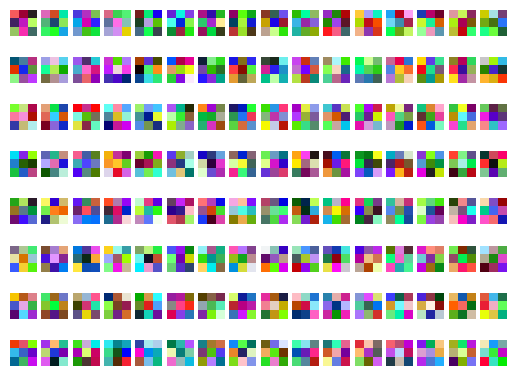

Train Epoch: 1 Loss: 1.5136: : 100% 45000/45000 [00:31<00:00, 1443.19it/s]
Eval Loss: 1.4307: : 100% 5000/5000 [00:18<00:00, 269.53it/s]
Train Epoch: 2 Loss: 1.1312: : 100% 45000/45000 [00:31<00:00, 1436.76it/s]
Eval Loss: 1.0679: : 100% 5000/5000 [00:25<00:00, 193.28it/s]
Train Epoch: 3 Loss: 1.1602: : 100% 45000/45000 [00:38<00:00, 1164.97it/s]
Eval Loss: 0.9508: : 100% 5000/5000 [00:26<00:00, 188.32it/s]
Train Epoch: 4 Loss: 0.7503: : 100% 45000/45000 [00:37<00:00, 1195.85it/s]
Eval Loss: 0.8285: : 100% 5000/5000 [00:18<00:00, 265.90it/s]
Train Epoch: 5 Loss: 0.8394: : 100% 45000/45000 [00:31<00:00, 1429.40it/s]
Eval Loss: 0.7479: : 100% 5000/5000 [00:24<00:00, 205.89it/s]
Train Epoch: 6 Loss: 0.6411: : 100% 45000/45000 [00:38<00:00, 1176.97it/s]
Eval Loss: 0.6555: : 100% 5000/5000 [00:20<00:00, 242.03it/s]
Train Epoch: 7 Loss: 0.4925: : 100% 45000/45000 [00:39<00:00, 1147.04it/s]
Eval Loss: 0.6042: : 100% 5000/5000 [00:25<00:00, 199.91it/s]
Train Epoch: 8 Loss: 0.7099: : 100% 45000

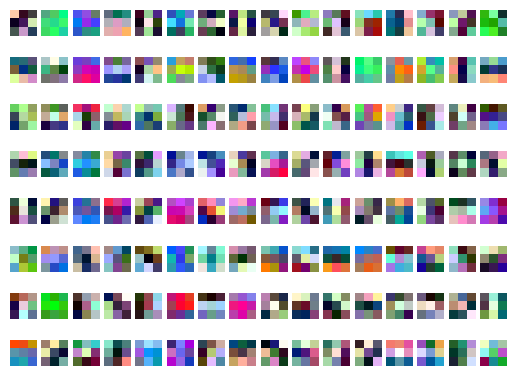

In [6]:
trainer_class = q1_config['trainer_module']
trainer_cnn = trainer_class(
    config = q1_config, 
    log_dir = ospj(PROJECT_ROOT,'Logs'),
    train_loader=train_data_loader, 
    eval_loader=valid_data_loader,
)

# Loading existing model weights
FORCE_TRAIN_Q1 = False

trainer_cnn.model.VisualizeFilter()

if FORCE_TRAIN_Q1:
    trainer_cnn.train()
else:
    print("Skipping training loop and loading pre-trained weights.")
    trainer_cnn.load_model(path='./Saved/CIFAR10_CNN/last_model.pth')

trainer_cnn.model.VisualizeFilter()

In [7]:
print(trainer_cnn.model)

ConvNet(
  (network): Sequential(
    (0): Conv2d(3, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (2): ReLU()
    (3): Conv2d(128, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): ReLU()
    (6): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): ReLU()
    (9): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (11): ReLU()
    (12): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): ReLU()
  )
  (output_layer): Linear(in_features=512, out_features=10, bias=True)
)Lay

In [8]:
# Change this to the experiment you want to evaluate
path = './Saved/CIFAR10_CNN/last_model.pth'

trainer_cnn.load_model(path=path)

result = trainer_cnn.evaluate(loader=test_loader)

print(result)

Eval Loss: 0.6998: : 100% 10000/10000 [00:18<00:00, 528.98it/s] 

{'loss': 0.6870341050624847, 'top1': 0.7681, 'top5': 0.9844999999999997}


#### Write your report for Q1 in this cell.

<br>
<br>
<br>

Q1 Report:

### Observations
* **Training and Eval loss:** Training and Eval loss at the end of **Epoch 1** were **1.5136** and **1.4307** respectively and at the end of **Epoch 10** were **0.4845** and **0.6178** respectively.

As an overview, both the training and eval loss have decreased from Epochs 1-10 although not necessarily in every consecutive epochs.

The total number of parameters which can be trained in the model is **7678474**.

### Question 2: Improve training of Convolutional Networks (15 points)

a) Batch normalization is a widely used operation in neural networks, which will increase the speed of convergence and reach higher performance. You can read the paper “Batch Normalization: Accelerating Deep Network Training by Reducing Internal Covariate Shift” for more theoretical details.
In practice, these operations are implemented in most toolboxes, such as PyTorch and TensorFlow. Add batch normalization in the model of Q1.a (You can use PyTorch's implementation). Please keep other hyperparameters the same, but only add batch normalization. The ConvNet with batch normalization still uses the same class with Q1.a but different arguments. Check the code for details. In each block, the computations should be in the order of **[convolution -> batch normalization -> pooling -> ReLU]**. Compare the loss curves and accuracy using batch normalization to its counterpart in Q1.a. (5 points)

In order to run this experiment, please create a new config dictionary in `cnn_cifar10.py` under the name `q2a_normalization_experiment` (Hint: most of it should be similar to Q1's config). Don't forget to assign the config a new name, so that it doesn't overwrite previous experiments. Similar to the above cells, import the config and run the experiment. 

You can also add extra code to `base_trainer.py` or `cnn_trainer.py` so that they return extra information after the training is finished. For example, recall that in assignment 2's `models/twolayernet/model.py` we had a train method that would return the history of loss values, and then in the notebook the history was plotted with matplotlib. Feel free to make adjustments that let you better understand what's happening. This also applies to next questions. Right now the code only uses tensorboard and wandb for plotting (if enabled in config).

Write your report for Q2.a in this cell. Feel free to add extra code cells

<br>

## Exercise 2.a Report: Impact of Batch Normalization

### Observations:
* **Best Performance:** The network achieved its lowest Validation Loss of **0.5179** quite early at **Epoch 10**. This represents a massive performance boost over vanilla Q1 baseline.
* **Convergence Acceleration:** Thanks to Batch Normalization reducing internal covariate shift, the model learned high-quality features incredibly quickly, hitting a low training loss (0.376) within the first 10 epochs.
* **Overfitting** Immediately after Epoch 10, the model began overfitting significantly. By Epoch 50, training Loss came down to almost perfect **0.0031**, while the validation loss rose and stayed around **0.6500**. 
* **Role of Batch Normalization:** Batch Normalization provided stability this is clear between Epochs 20 and 50 as even with severe overfitting, the validation loss did not completely explode or fluctuate wildly & it smoothly flattened out.

### Conclusion:
Batch Normalization successfully stabilized internal covariate shift and accelerated model convergence. But it lacks strong explicit regularization and cannot completely stop the model from memorizing the training dataset over 50 epochs.

In [ ]:
from cfgs.exercise_3 import cnn_cifar10

q2a_config = cnn_cifar10.q2a_normalization_experiment
q2b_config = cnn_cifar10.q2b_baseline_extended_experiment
q2c_config = cnn_cifar10.q2c_earlystop_experiment

datamodule_class = q2a_config['datamodule']
data_args = q2a_config['data_args']
dm_q2 = datamodule_class(**data_args)

train_loader_q2 = dm_q2.get_loader()
valid_loader_q2 = dm_q2.get_heldout_loader()

transforms for preset CIFAR10 for split train are Compose(
    ToTensor()
    Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
)
Initialization DataLoader for 45000 samples with {'batch_size': 200, 'shuffle': True, 'num_workers': 6}
Initialization heldout DataLoader 5000 samples with {'batch_size': 200, 'shuffle': False, 'num_workers': 6}


In [10]:
trainer_class = q2a_config['trainer_module']

trainer_bn = trainer_class(
    config=q2a_config, 
    log_dir=ospj(PROJECT_ROOT, 'Logs'),
    train_loader=train_loader_q2, 
    eval_loader=valid_loader_q2,
)

FORCE_TRAIN_Q2A = False

if FORCE_TRAIN_Q2A:
    print(f"Starting training for {q2a_config['name']} on device: {trainer_bn._device}")
    bn_history = trainer_bn.train()
else:
    print(f"Skipping training loop. Loading pre-trained best validation weights for {q2a_config['name']}.")
    # Load the best validation checkpoint for evaluation/plotting
    trainer_bn.load_model(path=ospj(trainer_bn.checkpoint_dir, 'best_val_model.pth'))

Warning! Log file ./Logs\CIFAR10_CNN_BatchNorm.log already exists! The logs will be appended!
Warning! Save dir Saved\CIFAR10_CNN_BatchNorm already exists!Existing checkpoints will be overwritten!
Starting training for CIFAR10_CNN_BatchNorm on device: cuda:0


Train Epoch: 1 Loss: 1.0181: : 100% 45000/45000 [00:32<00:00, 1379.40it/s]
Eval Loss: 1.3214: : 100% 5000/5000 [00:19<00:00, 261.10it/s]
Train Epoch: 2 Loss: 0.8085: : 100% 45000/45000 [00:35<00:00, 1269.39it/s]
Eval Loss: 0.9189: : 100% 5000/5000 [00:26<00:00, 186.35it/s]
Train Epoch: 3 Loss: 0.8225: : 100% 45000/45000 [00:42<00:00, 1066.84it/s]
Eval Loss: 1.1066: : 100% 5000/5000 [00:23<00:00, 217.06it/s]
Train Epoch: 4 Loss: 0.6995: : 100% 45000/45000 [00:39<00:00, 1128.03it/s]
Eval Loss: 0.7237: : 100% 5000/5000 [00:25<00:00, 193.74it/s]
Train Epoch: 5 Loss: 0.6185: : 100% 45000/45000 [00:40<00:00, 1113.22it/s]
Eval Loss: 0.8181: : 100% 5000/5000 [00:26<00:00, 188.18it/s] 
Train Epoch: 6 Loss: 0.5456: : 100% 45000/45000 [00:39<00:00, 1131.97it/s]
Eval Loss: 0.8045: : 100% 5000/5000 [00:25<00:00, 198.08it/s]
Train Epoch: 7 Loss: 0.4822: : 100% 45000/45000 [00:40<00:00, 1123.19it/s]
Eval Loss: 0.5286: : 100% 5000/5000 [00:25<00:00, 193.72it/s]
Train Epoch: 8 Loss: 0.5086: : 100% 4500

b) Throughout training, we optimize our parameters on the training set. This does not guarantee that with every step we also improve on validation and test set as well! Hence, there is no reason for our latest training checkpoint (the last checkpoint after the last epoch) to be the best to keep. One simple idea is to save a checkpoint of the best model for the validation set throughout the training. Meanining that as the training proceeds, we keep checking our **validation** accuracy after each epoch (or every N epochs) and save the best model. This can mitigate overfitting, as if the model overfits to training data (and accuracy on validation set drops), we would still have access to the best model checkpoint! Note that you **should not** do this on the test set, as we are not alowed to optimize **anything** (including the checkpoint selection) on the test set.

For this task, you need add the logic for saving the `best model` during the training. In the `src/trainers/base_trainer`, in method `train()` we already have the call to `self.evaluate()`. All you need to add is to process the returned result (a dictionary of metric_key -> metric_value) and see if you should save a checkpoint of the model. If yes, then you can save a checkpoint at `self.checkpoint_dir` under `best_val_model.pth` or a similar name, using the `save_model()` method. Feel free to define additional class attributes or methods if needed. 

We also recommend adding a few prints, such as the epochs that you save the best model at. You can also use the `self.logger` object.

Please also implement the `should_evaluate()` in the `trainers/base_tariner.py`, which allows for doing the cross-validation evaluation in intervals, based on the config.


Increase the training epochs to 50 in Q1.a and Q2.a (simply edit their config dictionaries), and compare the **best model** and **latest model** on the **training set** and **validation set**. Due to the randomness, you can train multiple times to verify and observe overfitting and early stopping. (5 points)


Feel free to add any needed train/evaluation code below for this task. 

In [ ]:
trainer_baseline_ext = trainer_class(
    config=q2b_config, 
    log_dir=ospj(PROJECT_ROOT, 'Logs'),
    train_loader=train_loader_q2, 
    eval_loader=valid_loader_q2,
)

FORCE_TRAIN_Q2B = False # Set to True when you want to run the training loop

if FORCE_TRAIN_Q2B:
    print(f"Starting 50-epoch training for {q2b_config['name']}.")
    baseline_ext_history = trainer_baseline_ext.train()
else:
    print(f"Skipping training loop & loading saved checkpoints for evaluation.")
    
    # To evaluate best validation model
    print("\nEvaluating Best Validation Model: ")
    trainer_baseline_ext.load_model(path=ospj(trainer_baseline_ext.checkpoint_dir, 'best_val_model.pth'))
    best_on_train = trainer_baseline_ext.evaluate(loader=train_loader_q2)
    best_on_val = trainer_baseline_ext.evaluate(loader=valid_loader_q2)
    print(f"Best Model on Training Set: Top-1 Acc = {best_on_train['top1']:.4f}, Loss = {best_on_train['loss']:.4f}")
    print(f"Best Model on Validation Set: Top-1 Acc = {best_on_val['top1']:.4f}, Loss = {best_on_val['loss']:.4f}")
    
    # Evaluate the Latest Model (at Epoch 50)
    print("\nEvaluating Latest Model (Epoch 50): ")
    trainer_baseline_ext.load_model(path=ospj(trainer_baseline_ext.checkpoint_dir, 'last_model.pth'))
    last_on_train = trainer_baseline_ext.evaluate(loader=train_loader_q2)
    last_on_val = trainer_baseline_ext.evaluate(loader=valid_loader_q2)
    print(f"Latest Model on Training Set: Top-1 Acc = {last_on_train['top1']:.4f}, Loss = {last_on_train['loss']:.4f}")
    print(f"Latest Model on Validation Set: Top-1 Acc = {last_on_val['top1']:.4f}, Loss = {last_on_val['loss']:.4f}")

Warning! Log file ./Logs\CIFAR10_CNN_Extended.log already exists! The logs will be appended!
Warning! Save dir Saved\CIFAR10_CNN_Extended already exists!Existing checkpoints will be overwritten!
Starting 50-epoch training for CIFAR10_CNN_Extended.


Train Epoch: 1 Loss: 1.5047: : 100% 45000/45000 [00:37<00:00, 1190.82it/s]
Eval Loss: 1.5150: : 100% 5000/5000 [00:22<00:00, 223.42it/s]
Train Epoch: 2 Loss: 0.9607: : 100% 45000/45000 [00:30<00:00, 1475.93it/s]
Eval Loss: 1.1783: : 100% 5000/5000 [00:19<00:00, 251.95it/s]
Train Epoch: 3 Loss: 0.7588: : 100% 45000/45000 [00:34<00:00, 1295.70it/s]
Eval Loss: 0.9164: : 100% 5000/5000 [00:26<00:00, 187.40it/s]
Train Epoch: 4 Loss: 0.8303: : 100% 45000/45000 [00:38<00:00, 1154.19it/s]
Eval Loss: 0.8500: : 100% 5000/5000 [00:19<00:00, 258.08it/s]
Train Epoch: 5 Loss: 0.7268: : 100% 45000/45000 [00:30<00:00, 1463.34it/s]
Eval Loss: 0.6742: : 100% 5000/5000 [00:19<00:00, 260.77it/s]
Train Epoch: 6 Loss: 0.6230: : 100% 45000/45000 [00:31<00:00, 1441.31it/s]
Eval Loss: 0.7350: : 100% 5000/5000 [00:23<00:00, 215.62it/s]
Train Epoch: 7 Loss: 0.5958: : 100% 45000/45000 [00:36<00:00, 1228.21it/s]
Eval Loss: 0.6585: : 100% 5000/5000 [00:23<00:00, 216.31it/s]
Train Epoch: 8 Loss: 0.5092: : 100% 45000

Wirte your report for Q2.b in this cell. Feel free to add extra code cells

<br>

## Exercise 2.b Report: Extended Vanilla Baseline

### Observations
* **Peak Generalization Point:** The unregularized vanilla CNN achieved its best validation performance early at **Epoch 13**, hitting its lowest Validation Loss of **0.5670**.
* **Overfitting:** By Epoch 50, the Training Loss dropped to an almost perfect **0.0216** (showing near-total memorization), while the Validation Loss degraded significantly, climbing up to **0.9207**. Because this baseline network lacks any explicit normalization (BatchNorm) or structural regularization (Dropout, Data Augmentation), the network has too much capacity to simply memorize the pixel noise of the training data.
* **Comparison with Q2.a (BatchNorm):**
  - Without BatchNorm, this extended baseline converges more slowly, requiring 13 epochs to hit its peak validation score compared to BatchNorm's 10 epochs.
  - Also, without BatchNorm's internal stabilization, the overfitting is very aggressive as the final validation loss here degraded all the way to **0.9207**, whereas the BatchNorm run plateaued around **0.6498**.

### Conclusion:
This experiment demonstrates the classic "overfitting curve" where training longer without regularization actively harms generalization performance. Running all 50 epochs was mathematically counterproductive, proving the need for **Early Stopping (Q2.c)** to clip training at Epoch 13.

c) While in part `b` we save the best model, we still do as many epochs as indicated in the config file. This is not convenient as the overfitting steps are wasting time and compute and also wouldn't affect the best model. Hence, Early Stopping can be helpful, where we **stop** the training after a few non-improving steps! Early stopping logic should be considered after every training epoch is finished, to see if we should do more epochs or not. Therefore, the logic should should be implemented ath the end of the loop over epochs in the `train()` method of `base_trainer.py` (which takes care of running multiple epochs).

Once implemented, you need a new config dictionary to enable early stopping. Simply create a new one at the bottom of `cfgs/exercise-3/cnn_cifar10.py`. It should be mostly similar to previous config, with the following modification:
```Python
q2c_earlystop_experiment = dict(
    name = 'Some New Name' # Otherwise it will overwrite previous experiment!
    ...
    trainer = dict(
        ...
        monitor = "off", # -> chante to "max eval_top1"
        early_stop = 0, #  -> change to 4
    ),
)
```
This will enable the early stopping to be considered for `eval_top1` metric and the maximum number of non-improving steps will be set to 4.

Use the cells below to re-run one of the experiments from part `b` that the best epoch was way lower than the total number of epochs, and see if early stopping can prevent unnecessary training epochs in that case.

In [ ]:
trainer_earlystop = trainer_class(
    config=q2c_config, 
    log_dir=ospj(PROJECT_ROOT, 'Logs'),
    train_loader=train_loader_q2, 
    eval_loader=valid_loader_q2,
)

FORCE_TRAIN_Q2C = False  # Set to True when you want to run the training loop

if FORCE_TRAIN_Q2C:
    print(f"Starting training for {q2c_config['name']} with Early Stopping (Patience = 4).")
    earlystop_history = trainer_earlystop.train()
else:
    print(f"Skipping training loop & loading saved early stop checkpoint.")
    trainer_earlystop.load_model(path=ospj(trainer_earlystop.checkpoint_dir, 'best_val_model.pth'))
    
    # Evaluate early stopped performance
    early_val_result = trainer_earlystop.evaluate(loader=valid_loader_q2)
    print(f"Early Stopped Model Validation Top-1 Accuracy: {early_val_result['top1']:.4f}")

Warning! Log file ./Logs\CIFAR10_CNN_EarlyStop.log already exists! The logs will be appended!
Warning! Save dir Saved\CIFAR10_CNN_EarlyStop already exists!Existing checkpoints will be overwritten!
Starting training for CIFAR10_CNN_EarlyStop with Early Stopping (Patience = 4).


Train Epoch: 1 Loss: 0.9543: : 100% 45000/45000 [00:34<00:00, 1315.55it/s]
Eval Loss: 1.5473: : 100% 5000/5000 [00:18<00:00, 277.15it/s]
Train Epoch: 2 Loss: 0.9275: : 100% 45000/45000 [00:31<00:00, 1430.42it/s]
Eval Loss: 1.6866: : 100% 5000/5000 [00:18<00:00, 276.14it/s]
Train Epoch: 3 Loss: 0.8035: : 100% 45000/45000 [00:31<00:00, 1424.52it/s]
Eval Loss: 1.0141: : 100% 5000/5000 [00:18<00:00, 275.32it/s]
Train Epoch: 4 Loss: 0.7453: : 100% 45000/45000 [00:31<00:00, 1442.87it/s]
Eval Loss: 0.8129: : 100% 5000/5000 [00:18<00:00, 272.43it/s]
Train Epoch: 5 Loss: 0.5033: : 100% 45000/45000 [00:31<00:00, 1445.36it/s]
Eval Loss: 0.7469: : 100% 5000/5000 [00:18<00:00, 274.81it/s]
Train Epoch: 6 Loss: 0.5111: : 100% 45000/45000 [00:31<00:00, 1444.89it/s]
Eval Loss: 0.7022: : 100% 5000/5000 [00:18<00:00, 270.80it/s]
Train Epoch: 7 Loss: 0.4289: : 100% 45000/45000 [00:31<00:00, 1429.14it/s]
Eval Loss: 0.6673: : 100% 5000/5000 [00:18<00:00, 274.29it/s]
Train Epoch: 8 Loss: 0.4915: : 100% 45000

Write your report for Q2.c in this cell.

Feel free to add extra code cells

<br>

## Exercise 2.c Report: Early Stopping

### Observations
* **Peak Generalization Point:** The network reached its absolute lowest Validation Loss of **0.4904** during **Epoch 15**. 
* **The Early Stopping Breakout:** 
  - Following the peak at Epoch 15, the model began to overfit during Epoch 16, with its validation loss ticking back up to **0.5103**.
  - Since the validation metrics failed to improve upon the Epoch 15 benchmark, the tracking loop flags the stagnation and terminates process.
* **Preventing Wasted Training:** In our extended baseline run (Q2.b), the model dragged on for a full 50 epochs despite its validation performance stalling early on. With Early Stopping active, the loop cut off training immediately after the overfitting inflection point.

### Conclusion 
Early Stopping prevents the model from sliding into severe training set memorization (overfitting) and cuts off training the moment validation gains stall. This gives peak model accuracy (Validation Loss: 0.4904) with maximum efficiency.

### Question 3: Improve generalization of Convolutional Networks (10 points)

We saw in Q2 that the model can start over-fitting to the training set if we continue training for long. To prevent over-fitting, there are two main paradigms we can focus on. 

The first is to get more training data. This might be a difficult and expensive process. However, it is generally the most effective way to learn more general models. A cheaper alternative is to perform data augmentation. The second approach is to regularize the model to prevent overfitting. 

In the following sub-questions, we will experiment with each of these paradigms and measure the effect on the model generalization. We recommend disabling Early Stopping from previous question (simply removing it from config file) so that it does not interrupt your experiments with data augmentations and you maintain full control over number of epochs.



a) Data augmentation is the process of creating more training data by applying certain transformations to the training set images. Usually, the underlying assumption is that the label of the image does not change under the applied transformations. This includes geometric transformations like translation, rotation, scaling, flipping, random cropping, and color transformations like greyscale, colorjitter. For every image in the training batch, a random transformation is sampled from the possible ones (e.g., a random number of pixels to translate the image by) and is applied to the image. While designing the data input pipeline, we must choose the hyper-parameters for these transformations (e.g., limits of translation or rotation) based on things we expect to see in the test-set/real world. Your task in this question is to implement the data augmentation for the CIFAR-10 classification task. Many of these transformations are implemented in the `torchvision.transforms` package. Familiarize yourself with the APIs of these transforms, and functions to compose multiple transforms or randomly sample them. Next, implement geometric and color space data augmentations for the CIFAR-10 dataset, by choosing the right functions and order of application. Tune the hyper-parameters of these data augmentations to improve the validation performance. You will need to train the model a bit longer (20-30 epochs) with data augmentation, as the training data is effectively larger now. Discuss which augmentations work well for you in the report. (6 points)

Create as many config dictionaries as you need in `cnn_cifar10.py`. For every augmentation, simply create a new preset under `src/utils/transform_presets.py` and reference its name in your experiment's config dict.



b) Dropout is a popular scheme to regularize the model to improve generalization. The dropout layer works by setting the input activations randomly to zero at the output. You can implement Dropout by adding the `torch.nn.Dropout` layer between the conv blocks in your model. The layer has a single hyper-parameter $p$, which is the probability of dropping the input activations. High values of $p$ regularize the model heavily and decrease model capacity, but with low values, the model might overfit. Find the right hyper-parameter for $p$ by training the model for different values of $p$ and comparing training validation and validation accuracies. You can use the same parameter $p$ for all layers. You can also disable the data augmentation from the previous step while running this experiment, to clearly see the benefit of dropout. Show the plot of training and validation accuracies for different values of dropout (0.1 - 0.9) in the report. Create as many config dictionaries as you need in `cnn_cifar10.py`. (4 points)

transforms for preset CIFAR10_WithFlip for split train are Compose(
    RandomHorizontalFlip(p=0.5)
    RandomCrop(size=(32, 32), padding=4)
    ToTensor()
    Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
)
Initialization DataLoader for 45000 samples with {'batch_size': 200, 'shuffle': True, 'num_workers': 6}
Initialization heldout DataLoader 5000 samples with {'batch_size': 200, 'shuffle': False, 'num_workers': 6}

Launching Training Run for: CIFAR10_CNN_Aug1_Geometric.


Train Epoch: 1 Loss: 1.2794: : 100% 45000/45000 [00:31<00:00, 1432.71it/s]
Eval Loss: 1.3685: : 100% 5000/5000 [00:18<00:00, 270.03it/s]
Train Epoch: 2 Loss: 0.9889: : 100% 45000/45000 [00:31<00:00, 1430.72it/s]
Eval Loss: 1.0762: : 100% 5000/5000 [00:18<00:00, 276.84it/s]
Train Epoch: 3 Loss: 0.7538: : 100% 45000/45000 [00:31<00:00, 1429.39it/s]
Eval Loss: 2.0882: : 100% 5000/5000 [00:18<00:00, 277.00it/s]
Train Epoch: 4 Loss: 0.8496: : 100% 45000/45000 [00:31<00:00, 1436.31it/s]
Eval Loss: 0.8644: : 100% 5000/5000 [00:17<00:00, 279.61it/s]
Train Epoch: 5 Loss: 0.7566: : 100% 45000/45000 [00:31<00:00, 1442.94it/s]
Eval Loss: 0.8473: : 100% 5000/5000 [00:18<00:00, 272.66it/s]
Train Epoch: 6 Loss: 0.7013: : 100% 45000/45000 [00:31<00:00, 1443.37it/s]
Eval Loss: 0.7586: : 100% 5000/5000 [00:18<00:00, 271.36it/s]
Train Epoch: 7 Loss: 0.6982: : 100% 45000/45000 [00:31<00:00, 1447.27it/s]
Eval Loss: 0.7072: : 100% 5000/5000 [00:18<00:00, 274.04it/s]
Train Epoch: 8 Loss: 0.5446: : 100% 45000

transforms for preset CIFAR10_ColorJitter for split train are Compose(
    ColorJitter(brightness=(0.7, 1.3), contrast=(0.7, 1.3), saturation=(0.7, 1.3), hue=(-0.1, 0.1))
    ToTensor()
    Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
)
Initialization DataLoader for 45000 samples with {'batch_size': 200, 'shuffle': True, 'num_workers': 6}
Initialization heldout DataLoader 5000 samples with {'batch_size': 200, 'shuffle': False, 'num_workers': 6}

Launching Training Run for: CIFAR10_CNN_Aug2_Color.


Train Epoch: 1 Loss: 1.0820: : 100% 45000/45000 [00:31<00:00, 1435.55it/s]
Eval Loss: 1.2095: : 100% 5000/5000 [00:18<00:00, 276.72it/s]
Train Epoch: 2 Loss: 0.9203: : 100% 45000/45000 [00:31<00:00, 1429.26it/s]
Eval Loss: 1.2043: : 100% 5000/5000 [00:18<00:00, 276.32it/s]
Train Epoch: 3 Loss: 0.8548: : 100% 45000/45000 [00:31<00:00, 1442.01it/s]
Eval Loss: 0.9107: : 100% 5000/5000 [00:17<00:00, 278.59it/s]
Train Epoch: 4 Loss: 0.7245: : 100% 45000/45000 [00:31<00:00, 1446.87it/s]
Eval Loss: 0.8240: : 100% 5000/5000 [00:18<00:00, 270.65it/s]
Train Epoch: 5 Loss: 0.8005: : 100% 45000/45000 [00:31<00:00, 1440.43it/s]
Eval Loss: 0.7869: : 100% 5000/5000 [00:18<00:00, 270.66it/s]
Train Epoch: 6 Loss: 0.6064: : 100% 45000/45000 [00:31<00:00, 1449.59it/s]
Eval Loss: 0.8064: : 100% 5000/5000 [00:18<00:00, 272.85it/s]
Train Epoch: 7 Loss: 0.5473: : 100% 45000/45000 [00:31<00:00, 1429.79it/s]
Eval Loss: 0.7618: : 100% 5000/5000 [00:18<00:00, 276.27it/s]
Train Epoch: 8 Loss: 0.4642: : 100% 45000

transforms for preset CIFAR10_HeavyAug for split train are Compose(
    RandomHorizontalFlip(p=0.5)
    RandomCrop(size=(32, 32), padding=4)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=(-0.1, 0.1))
    ToTensor()
    Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
)
Initialization DataLoader for 45000 samples with {'batch_size': 200, 'shuffle': True, 'num_workers': 6}
Initialization heldout DataLoader 5000 samples with {'batch_size': 200, 'shuffle': False, 'num_workers': 6}

Launching Training Run for: CIFAR10_CNN_Aug3_Heavy.


Train Epoch: 1 Loss: 1.3158: : 100% 45000/45000 [00:31<00:00, 1425.42it/s]
Eval Loss: 1.6818: : 100% 5000/5000 [00:18<00:00, 276.85it/s]
Train Epoch: 2 Loss: 1.0897: : 100% 45000/45000 [00:31<00:00, 1437.24it/s]
Eval Loss: 1.8421: : 100% 5000/5000 [00:18<00:00, 276.76it/s]
Train Epoch: 3 Loss: 1.1053: : 100% 45000/45000 [00:31<00:00, 1443.88it/s]
Eval Loss: 1.4478: : 100% 5000/5000 [00:18<00:00, 271.46it/s]
Train Epoch: 4 Loss: 1.0429: : 100% 45000/45000 [00:31<00:00, 1432.56it/s]
Eval Loss: 1.1071: : 100% 5000/5000 [00:19<00:00, 258.24it/s]
Train Epoch: 5 Loss: 0.8953: : 100% 45000/45000 [00:31<00:00, 1411.26it/s]
Eval Loss: 1.0146: : 100% 5000/5000 [00:18<00:00, 268.52it/s]
Train Epoch: 6 Loss: 0.8131: : 100% 45000/45000 [00:31<00:00, 1422.73it/s]
Eval Loss: 0.9318: : 100% 5000/5000 [00:18<00:00, 273.03it/s]
Train Epoch: 7 Loss: 0.8020: : 100% 45000/45000 [00:31<00:00, 1423.40it/s]
Eval Loss: 0.8465: : 100% 5000/5000 [00:17<00:00, 278.10it/s]
Train Epoch: 8 Loss: 0.7903: : 100% 45000

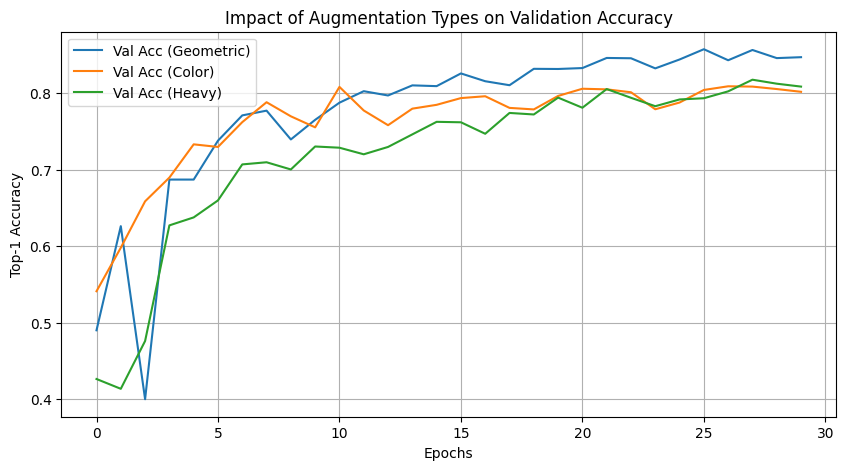

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

AUG_PLOT_PATH = os.path.join(PROJECT_ROOT, 'augmentation_plots.png')

augmentation_configs = [
    cnn_cifar10.q3a_aug1_experiment,
    cnn_cifar10.q3a_aug2_experiment,
    cnn_cifar10.q3a_aug3_experiment
]

aug_histories = {}
trainer_class = cnn_cifar10.q1_experiment['trainer_module']

FORCE_TRAIN_Q3A_ALL = False

if FORCE_TRAIN_Q3A_ALL:
    for config in augmentation_configs:
        # Dedicated isolated loaders for each
        dm = config['datamodule'](**config['data_args'])
        trainer = trainer_class(
            config=config,
            log_dir=ospj(PROJECT_ROOT, 'Logs'),
            train_loader=dm.get_loader(),
            eval_loader=dm.get_heldout_loader()
        )
        print(f"\nLaunching Training Run for: {config['name']}.")
        history = trainer.train()
        aug_histories[config['name']] = history
        
    # Performance of the Augmentations
    plt.figure(figsize=(10, 5))
    for name, history in aug_histories.items():
        plt.plot(history['eval_top1'], label=f"Val Acc ({name.split('_')[-1]})")
    plt.title('Impact of Augmentation Types on Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Top-1 Accuracy')
    plt.legend()
    plt.grid(True)
    plt.savefig(AUG_PLOT_PATH, dpi=300)
    plt.show()
else:
    print("Skipping active training blocks as results are stored in checkpoints folder.")
    if os.path.exists(AUG_PLOT_PATH):
        img = mpimg.imread(AUG_PLOT_PATH)
        plt.imshow(img)
        plt.show() 
    else:
        print(f"ERROR: Could not find your image at path: {AUG_PLOT_PATH}\n"
              "Please check if the filename or folder matches where you saved it!")

transforms for preset CIFAR10 for split train are Compose(
    ToTensor()
    Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
)
Initialization DataLoader for 45000 samples with {'batch_size': 200, 'shuffle': True, 'num_workers': 6}
Initialization heldout DataLoader 5000 samples with {'batch_size': 200, 'shuffle': False, 'num_workers': 6}
30-Epoch Sweep Window for Dropout Rate: p = 0.1


Train Epoch: 1 Loss: 0.9011: : 100% 45000/45000 [00:33<00:00, 1357.71it/s]
Eval Loss: 1.3747: : 100% 5000/5000 [00:18<00:00, 263.56it/s]
Train Epoch: 2 Loss: 0.9812: : 100% 45000/45000 [00:32<00:00, 1402.62it/s]
Eval Loss: 1.0779: : 100% 5000/5000 [00:18<00:00, 270.16it/s]
Train Epoch: 3 Loss: 0.7695: : 100% 45000/45000 [00:31<00:00, 1409.34it/s]
Eval Loss: 1.5127: : 100% 5000/5000 [00:18<00:00, 272.15it/s]
Train Epoch: 4 Loss: 0.5583: : 100% 45000/45000 [00:31<00:00, 1421.63it/s]
Eval Loss: 0.8592: : 100% 5000/5000 [00:18<00:00, 276.49it/s]
Train Epoch: 5 Loss: 0.6450: : 100% 45000/45000 [00:32<00:00, 1391.97it/s]
Eval Loss: 0.7403: : 100% 5000/5000 [00:18<00:00, 272.68it/s]
Train Epoch: 6 Loss: 0.5481: : 100% 45000/45000 [00:32<00:00, 1405.71it/s]
Eval Loss: 0.6395: : 100% 5000/5000 [00:18<00:00, 272.73it/s]
Train Epoch: 7 Loss: 0.4633: : 100% 45000/45000 [00:31<00:00, 1423.24it/s]
Eval Loss: 0.6279: : 100% 5000/5000 [00:18<00:00, 268.13it/s]
Train Epoch: 8 Loss: 0.6821: : 100% 45000

transforms for preset CIFAR10 for split train are Compose(
    ToTensor()
    Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
)
Initialization DataLoader for 45000 samples with {'batch_size': 200, 'shuffle': True, 'num_workers': 6}
Initialization heldout DataLoader 5000 samples with {'batch_size': 200, 'shuffle': False, 'num_workers': 6}
30-Epoch Sweep Window for Dropout Rate: p = 0.3


Train Epoch: 1 Loss: 1.0713: : 100% 45000/45000 [00:31<00:00, 1427.84it/s]
Eval Loss: 1.1532: : 100% 5000/5000 [00:18<00:00, 269.45it/s]
Train Epoch: 2 Loss: 0.9945: : 100% 45000/45000 [00:31<00:00, 1429.09it/s]
Eval Loss: 1.0386: : 100% 5000/5000 [00:18<00:00, 273.80it/s]
Train Epoch: 3 Loss: 0.9712: : 100% 45000/45000 [00:31<00:00, 1436.44it/s]
Eval Loss: 0.9546: : 100% 5000/5000 [00:18<00:00, 268.40it/s]
Train Epoch: 4 Loss: 0.8762: : 100% 45000/45000 [00:32<00:00, 1400.68it/s]
Eval Loss: 0.9606: : 100% 5000/5000 [00:18<00:00, 271.59it/s]
Train Epoch: 5 Loss: 0.8495: : 100% 45000/45000 [00:32<00:00, 1396.60it/s]
Eval Loss: 0.7935: : 100% 5000/5000 [00:18<00:00, 275.73it/s]
Train Epoch: 6 Loss: 0.7457: : 100% 45000/45000 [00:31<00:00, 1417.43it/s]
Eval Loss: 0.7079: : 100% 5000/5000 [00:18<00:00, 271.67it/s]
Train Epoch: 7 Loss: 0.6482: : 100% 45000/45000 [00:31<00:00, 1415.79it/s]
Eval Loss: 0.8373: : 100% 5000/5000 [00:18<00:00, 272.45it/s]
Train Epoch: 8 Loss: 0.7072: : 100% 45000

transforms for preset CIFAR10 for split train are Compose(
    ToTensor()
    Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
)
Initialization DataLoader for 45000 samples with {'batch_size': 200, 'shuffle': True, 'num_workers': 6}
Initialization heldout DataLoader 5000 samples with {'batch_size': 200, 'shuffle': False, 'num_workers': 6}
30-Epoch Sweep Window for Dropout Rate: p = 0.5


Train Epoch: 1 Loss: 1.1072: : 100% 45000/45000 [00:32<00:00, 1397.25it/s]
Eval Loss: 1.4621: : 100% 5000/5000 [00:18<00:00, 272.05it/s]
Train Epoch: 2 Loss: 1.0395: : 100% 45000/45000 [00:32<00:00, 1395.72it/s]
Eval Loss: 1.2678: : 100% 5000/5000 [00:18<00:00, 264.43it/s]
Train Epoch: 3 Loss: 1.0431: : 100% 45000/45000 [00:32<00:00, 1371.87it/s]
Eval Loss: 0.9572: : 100% 5000/5000 [00:18<00:00, 263.93it/s]
Train Epoch: 4 Loss: 0.9760: : 100% 45000/45000 [00:31<00:00, 1406.48it/s]
Eval Loss: 1.0769: : 100% 5000/5000 [00:18<00:00, 265.89it/s]
Train Epoch: 5 Loss: 1.0350: : 100% 45000/45000 [00:32<00:00, 1400.75it/s]
Eval Loss: 1.1079: : 100% 5000/5000 [00:18<00:00, 271.30it/s]
Train Epoch: 6 Loss: 0.8495: : 100% 45000/45000 [00:32<00:00, 1395.82it/s]
Eval Loss: 0.8203: : 100% 5000/5000 [00:18<00:00, 272.38it/s]
Train Epoch: 7 Loss: 0.8956: : 100% 45000/45000 [00:32<00:00, 1381.97it/s]
Eval Loss: 0.8172: : 100% 5000/5000 [00:18<00:00, 271.49it/s]
Train Epoch: 8 Loss: 0.8460: : 100% 45000

transforms for preset CIFAR10 for split train are Compose(
    ToTensor()
    Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
)
Initialization DataLoader for 45000 samples with {'batch_size': 200, 'shuffle': True, 'num_workers': 6}
Initialization heldout DataLoader 5000 samples with {'batch_size': 200, 'shuffle': False, 'num_workers': 6}
30-Epoch Sweep Window for Dropout Rate: p = 0.7


Train Epoch: 1 Loss: 1.5457: : 100% 45000/45000 [00:31<00:00, 1407.25it/s]
Eval Loss: 1.7181: : 100% 5000/5000 [00:18<00:00, 273.36it/s]
Train Epoch: 2 Loss: 1.3158: : 100% 45000/45000 [00:32<00:00, 1380.88it/s]
Eval Loss: 1.6440: : 100% 5000/5000 [00:23<00:00, 212.28it/s]
Train Epoch: 3 Loss: 1.3017: : 100% 45000/45000 [00:32<00:00, 1405.56it/s]
Eval Loss: 1.3547: : 100% 5000/5000 [00:18<00:00, 273.05it/s]
Train Epoch: 4 Loss: 1.1805: : 100% 45000/45000 [00:31<00:00, 1425.85it/s]
Eval Loss: 1.5368: : 100% 5000/5000 [00:18<00:00, 274.78it/s]
Train Epoch: 5 Loss: 1.2685: : 100% 45000/45000 [00:31<00:00, 1425.96it/s]
Eval Loss: 1.1672: : 100% 5000/5000 [00:18<00:00, 265.34it/s]
Train Epoch: 6 Loss: 1.3041: : 100% 45000/45000 [00:31<00:00, 1419.27it/s]
Eval Loss: 1.2940: : 100% 5000/5000 [00:18<00:00, 265.23it/s]
Train Epoch: 7 Loss: 1.2771: : 100% 45000/45000 [00:31<00:00, 1409.94it/s]
Eval Loss: 1.2930: : 100% 5000/5000 [00:18<00:00, 271.46it/s]
Train Epoch: 8 Loss: 1.0368: : 100% 45000


Training completed.


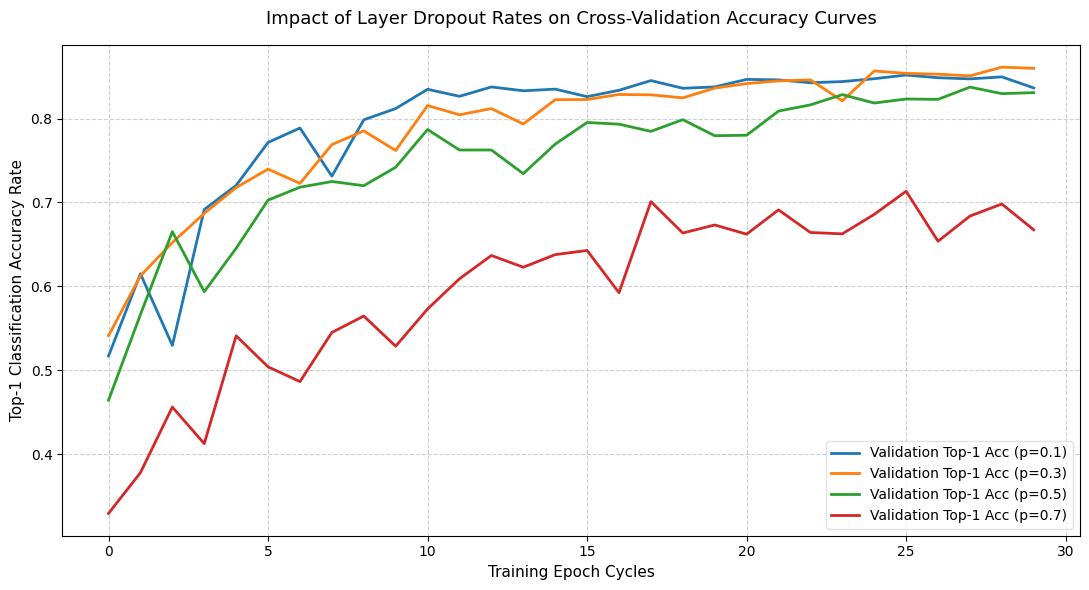

Success! Performance matrix plot captured safely to: ./dropout_sweep_plot.png


In [ ]:
import matplotlib.image as mpimg
import os

q3b_base_config = cnn_cifar10.q3b_dropout_experiment
dropout_rates = [0.1, 0.3, 0.5, 0.7]
dropout_histories = {}

PLOT_OUTPUT_PATH = os.path.join(PROJECT_ROOT, 'dropout_sweep_plot.png')

FORCE_TRAIN_Q3B_SWEEP = False  # Toggle to False once executed locally to lock results

if FORCE_TRAIN_Q3B_SWEEP:
    for p in dropout_rates:
        sweep_config = deepcopy(q3b_base_config)
        sweep_config['name'] = f"CIFAR10_CNN_Dropout_p_{str(p).replace('.', '_')}"
        sweep_config['model_args']['drop_prob'] = p
        
        dm_sweep = sweep_config['datamodule'](**sweep_config['data_args'])
        
        trainer_sweep = sweep_config['trainer_module'](
            config=sweep_config,
            log_dir=ospj(PROJECT_ROOT, 'Logs'),
            train_loader=dm_sweep.get_loader(),
            eval_loader=dm_sweep.get_heldout_loader()
        )
        print(f"30-Epoch Sweep Window for Dropout Rate: p = {p}")
        history = trainer_sweep.train()
        dropout_histories[p] = history

    print("\nTraining completed.")
    plt.figure(figsize=(11, 6))
    for p in dropout_rates:
        val_acc_trajectory = dropout_histories[p]['eval_top1']
        plt.plot(val_acc_trajectory, label=f"Validation Top-1 Acc (p={p})", linewidth=2)
        
    plt.title('Impact of Layer Dropout Rates on Cross-Validation Accuracy Curves', fontsize=13, pad=15)
    plt.xlabel('Training Epoch Cycles', fontsize=11)
    plt.ylabel('Top-1 Classification Accuracy Rate', fontsize=11)
    plt.legend(loc='lower right', frameon=True, facecolor='white', edgecolor='gainsboro')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig(PLOT_OUTPUT_PATH, dpi=300)
    plt.show()
    print(f"Success! Performance matrix plot captured safely to: {PLOT_OUTPUT_PATH}")

else:
    print("Skipping active dropout training blocks. Pulling static pre-rendered visual arrays.")
    if os.path.exists(PLOT_OUTPUT_PATH):
        img = mpimg.imread(PLOT_OUTPUT_PATH)
        plt.imshow(img)
        plt.show()  
    else:
        print(f"ERROR: No cached asset detected at path: {PLOT_OUTPUT_PATH}\n"
              "Please toggle FORCE_TRAIN_Q3B_SWEEP = True and run once to generate files.")

Write your report for Q3 in this cell. Feel free to add extra code cells

<br>

## Exercise 3.a Report: Comparing Data Augmentation Strategies

### Observations
Looking at the final validation trajectories over the 30-epoch training window, we observe:

* **Augmentation 1 (Geometric Only):** Hit a highly impressive peak validation accuracy of **~85.5%** (lowest console `Eval Loss: 0.3969` at Epoch 30).
* **Augmentation 2 (Color Only):** Peaked at roughly **~81.0%** validation accuracy, with its optimal performance hitting around Epoch 28 (`Eval Loss: 0.6371`).
* **Augmentation 3 (Heavy Combined):** Reached a peak validation accuracy of **~82.0%** near the end of the run at Epoch 27 (`Eval Loss: 0.4817`).

### Which Augmentations Worked Best?

#### Best: Geometric Augmentations (Random Flipping + Random Cropping)
As shown in the plot, the blue curve (**Geometric**) consistently outperforms all other approaches after Epoch 10. 
CIFAR-10 contains object classes such as cars, birds, ships, planes where left-to-right alignment and positioning vary heavily in real life, but structural shapes remain similar. Random horizontal flipping and cropping ($32\times32$ with padding=4) forces convolutional filters to learn spatial invariance so the network stops relying on strict absolute pixel coordinates and instead learns relative geometric boundaries.

#### Color Jittering:
The orange curve plateaus early on and fluctuates heavily. 
Shifting color distributions aggressively may have confused the model and challenged its intuition on a few images.(Eg: green fields for frogs/deer, blue backgrounds for ships/plane)

#### Combined Heavy Augmentation:
The green curve shows a much slower learning trajectory during the first 5 epochs, lagging down around 42-45% accuracy. 
It climbs steadily without plateauing. While it takes longer to train due to massive variety, it can eliminate overfitting. Given 50-60 epochs, this regularizer could surpass the geometric augmentation.


### Conclusion
Data augmentation prevents premature validation plateaus. For the custom CNN, the geometric flipping and cropping provides the most substantial generalization boost, raising the Top-1 validation score to an optimal ~85.5%.

## Exercise 3.b Report: Hyperparameter Sweep Analysis of Dropout Rates

### Observations:
By isolating regularization and training for 30 epochs on the vanilla data distribution, we observe a clear trade-off between network capacity and feature suppression across the different dropout probabilities ($p$):

* **Dropout $p=0.1$ (Blue Line):** Climbed quickly in the first 10 epochs, peaking at a validation accuracy of **~85.0%** before experiencing a bit of overfitting.
* **Dropout $p=0.3$ (Orange Line):** Most stable trajectory, achieving the highest overall validation accuracy peak at **~86.2%** near the final epoch (`Eval Loss: 0.3792` at Epoch 30).
* **Dropout $p=0.5$ (Green Line):** Slower start, but climbed steadily to plateau at a highly robust **~83.5%** validation accuracy (`Eval Loss: 0.4665` at Epoch 30).
* **Dropout $p=0.7$ (Red Line):** Severely underperformed across the entire run, and validation accuracy peak of **~71.0%** (`Eval Loss: 0.8851`).

#### Optimal: $p=0.3$
The orange validation curve (**$p=0.3$**) is the sweet spot for the custom network architecture. 
Deactivating 30% of neuron activations randomly during each forward pass make it such that neurons can no longer rely on the presence of specific neighboring features to classify an image. This forces the network to learn redundant features and stop memorizing specific noise from the training set.

#### Under Regularization ($p=0.1$) & Heavy Retention ($p=0.5$)
* **At $p=0.1$:** Dropping only 10% of activations provides insufficient regularization. The model converges very rapidly (reaching ~83.5% within 10 epochs), but because the capacity is reduced only a bit, the curve flattens out early and begins to overfit.
* **At $p=0.5$:** Cutting off half of all activations, the network learns at a significantly slower rate during the first 5 epochs, but its validation path scales up with exceptionally smooth, monotonically stable steps, indicating that the features it does manage to extract are highly robust.

#### Severe Underfitting ($p=0.7$)
The red curve (**$p=0.7$**) shows a huge drop in performance.
Dropping 70% of the channels at every block decimates the network's capacity. The gradient flow is disrupted and model passing info from first to last layer is changed. The model is in a permanent state of **underfitting** unable to fully learn the underlying data distribution due to its reduced complexity.


### Conclusion
Using dropout directly into our convolutional blocks effectively mitigates overfitting without altering data. A **p=0.3** dropout probability balances data memorization and capacity, maximizing Top-1 cross-validation accuracy at **~86.2%**.

### Question 4: Use pretrained networks (10 points)

It has become standard practice in computer vision tasks related to images to use a convolutional network pre-trained as the backbone feature extraction network and train new layers on top for the target task. In this question, we will implement such a model. We will use the `VGG_11_bn` network from the `torchvision.models` library as our backbone network. This model has been trained on ImageNet, achieving a top-5 error rate of 10.19%. It consists of 8 convolutional layers followed by adaptive average pooling and fully-connected layers to perform the classification. We will get rid of the average pooling and fully-connected layers from the `VGG_11_bn` model and attach our own fully connected layers to perform the CIFAR-10 classification.

a) Instantiate a pretrained version of the `VGG_11_bn` model with ImageNet pre-trained weights. Add two fully connected layers on top, with Batch Norm and ReLU layers in between them, to build the CIFAR-10 10-class classifier. Note that you will need to set the correct mean and variance in the data-loader, to match the mean and variance the data was normalized with when the `VGG_11_bn` was trained. Train only the newly added layers while disabling gradients for the rest of the network. Each parameter in PyTorch has a required grad flag, which can be turned off to disable gradient computation for it. Get familiar with this gradient control mechanism in PyTorch and train the above model. As a reference point, you will see validation accuracies in the range (61-65%) if implemented correctly. (6 points)

b) We can see that while the ImageNet features are useful, just learning the new layers does not yield better performance than training our own network from scratch. This is due to the domain-shift between the ImageNet dataset (224x224 resolution images) and the CIFAR-10 dataset (32x32 images). To improve the performance we can fine-tune the whole network on the CIFAR-10 dataset, starting from the ImageNet initialization (set `"fine_tune"` to `true` in `vgg_cifar10.py`). To do this, enable gradient computation to the rest of the network, and update all the model parameters. Additionally train a baseline model where the entire network is trained from scratch, without loading the ImageNet weights (set `"weights"` to `None` in `vgg_cifar10.py`). Compare the two models' training curves, validation, and testing performance in the report. (4 points)


If you're using Pytorch 1, the `weights` argument will not work. In that case, you need to change the `weights` argument to `pretrained=True` or `False`. Feel free to post on Forum if you have any issues.

For both questions, feel free to modify the data augmentation by defining a new preset and referring to it in the config file. However, make sure that in your experiments you always change only one thing at a time (i.e use the same augmentation for both method A and method B if you're comparing them with each other!)

In [13]:
%cd /content/computer-vision/Assignment_3
!pwd

/content/computer-vision/Assignment_3
/content/computer-vision/Assignment_3


In [14]:
from cfgs.exercise_3 import vgg_cifar10
q4_config = vgg_cifar10.q4_dict


datamodule_class = q4_config['datamodule']
data_args = q4_config['data_args']

dm = datamodule_class(**data_args)

# Based on the heldout_split in the config file, 
# the datamodule will break the dataset into two splits
train_data_loader = dm.get_loader()
valid_data_loader = dm.get_heldout_loader()

# Test loader is the same as train loader
# except that training=False, shuffle=False, and no splitting is done 
# So we use the exact config from training and just modify these arguments
test_data_args = deepcopy(data_args) # copy the args
test_data_args['training']=False
test_data_args['shuffle']=False
test_data_args['heldout_split']=0.0

# Now we initialize the test module with the modified config
test_dm = datamodule_class(**test_data_args)
test_loader = test_dm.get_loader() # and get the loader from it

transforms for preset CIFAR10_VGG for split train are Compose(
    ToTensor()
    Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
)


100%|██████████| 170M/170M [00:03<00:00, 50.9MB/s] 


Initialization DataLoader for 45000 samples with {'batch_size': 64, 'shuffle': True, 'num_workers': 6}
Initialization heldout DataLoader 5000 samples with {'batch_size': 64, 'shuffle': False, 'num_workers': 6}
transforms for preset CIFAR10_VGG for split eval are Compose(
    ToTensor()
    Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
)


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 6 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Initialization DataLoader for 10000 samples with {'batch_size': 64, 'shuffle': False, 'num_workers': 6}


 By default WandB is enabled in config file for `vgg_cifar10.py`. You can set it to false if you don't want to use it. It's not an essential part of the assignment anyway.

In [22]:
wandb_enabled = q4_config['trainer_config']['wandb']
if wandb_enabled:
    import wandb
    
    # change entity to your wandb username/group name. Also feel free to rename project and run names.
    run = wandb.init(
        project="HLCV-exercise-3", # Change the project name if you wish.
        name=q4_config['name'],
        config=q4_config,
        entity="Curious Puffin", # Replace the curious puffin with your WandB username :)
        dir=PROJECT_ROOT
    )
    run.name = run.name + f'-{run.id}'
    assert run is wandb.run


In [23]:
import torch
import torchvision
print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")

PyTorch version: 2.11.0+cpu
Torchvision version: 0.26.0+cpu


In [27]:
trainer_class = q4_config['trainer_module']
trainer_vgg = trainer_class(
    config = q4_config, 
    log_dir = ospj(PROJECT_ROOT,'Logs'),
    train_loader=train_data_loader, 
    eval_loader=valid_data_loader,
)

Warning! Log file ./Logs/CIFAR10_VGG.log already exists! The logs will be appended!
Warning! Save dir Saved/CIFAR10_VGG already exists!Existing checkpoints will be overwritten!


ValueError: optimizer got an empty parameter list

In [ ]:
trainer_vgg.train()

In [ ]:
# Change this to the experiment you want to evaluate
path = './Saved/CIFAR10_VGG/last_model.pth'

trainer_vgg.load_model(path=path)

result = trainer_vgg.evaluate(loader=test_loader)

print(result)

if wandb_enabled:
    for metrics, values in result.items():
        wandb.run.summary[f"test_{metrics}"] = values

    # Change the title and message as you wish.
    # Would only work if you have enabled push notifications for your email/slack in wandb account settings.
    # Of course not an essential part of the assignment :)
    wandb.alert(
        title="Training Finished",
        text=f'VGG Training has finished. Test results: {result}', level=wandb.AlertLevel.INFO
    )

    run.finish()

#### Write your report for Q4 in this cell.
Feel free to add more code cells if needed.

<br>
<br>
<br>